In [15]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import shutil
import importlib
from dataclasses import fields, asdict
import json
import time as time_module
from datetime import datetime, timedelta

import warnings as pywarnings
import gc as pygc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NetCDFDataset
from parcels import FieldSet, ParticleSet


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/run_particles_mr_sm.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

# Add the project root and the two postprocessing folders.
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
if str(PROJECT_DIR / "z.flow_postprocessing") not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / "z.flow_postprocessing"))
if str(PROJECT_DIR / "z.parcels_postprocessing") not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / "z.parcels_postprocessing"))


# Project modules
import scripts.fieldset as pfs
import scripts.particles as pparticles
import scripts.kernels_common as kcommon
import scripts.kernels_passive as kpassive
import scripts.kernels_mr_sm as kmrsm
import scripts.run as prun
import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme


for module in [
    pfs,
    pparticles,
    kcommon,
    kpassive,
    kmrsm,
    prun,
    phelp,
    ptheme,
]:
    importlib.reload(module)

ptheme.apply_theme()

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")
print(f"Parcels dir  : {PROJECT_DIR / 'z.parcels_postprocessing'}")
print(f"run.py loaded from: {Path(prun.__file__).resolve()}")
print(f"passive kernel loaded from: {Path(kpassive.__file__).resolve()}")
print(f"SM-MRG kernel loaded from: {Path(kmrsm.__file__).resolve()}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis
Parcels dir  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing
run.py loaded from: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\run.py
passive kernel loaded from: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\kernels_passive.py
SM-MRG kernel loaded from: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\kernels_mr_sm.py


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


In [ ]:
# ============================================================
# 2. DIRECTORY / CASE SETTINGS
# ============================================================

case_name = "run_may1"   
RUN_TITLE_INFO = "Case MAY-1 Production"  

INPUT_DIR = (NB_DIR / "../data/input").resolve()
DATA_FILE = (INPUT_DIR / f"{case_name}.nc").resolve()

if not DATA_FILE.exists():
    available = sorted(p.name for p in INPUT_DIR.glob("*"))
    raise FileNotFoundError(
        f"Could not find input file:\n{DATA_FILE}\n\n"
        f"Available files in {INPUT_DIR}:\n"
        + "\n".join(available)
    )


# ============================================================
# 3. PARCELS ADVECTION SETTINGS
# ============================================================

DAY_PER_INDEX = 3.0 / 24.0
TIME_STEP_SECONDS = int(DAY_PER_INDEX * 86400)

RELEASE_TIME_INDEX = 0
LEVEL_INDICES = (0,)

RUNTIME_MODE = "manual"       # "manual" or "full_forcing"
RUNTIME_DAYS_REQUESTED = 14.0

DT_SECONDS = 300
OUTPUTDT_SECONDS = TIME_STEP_SECONDS

NX = 60
NY = 60

PERIODIC = True
RELEASE_MARGIN_CELLS = 1.0

# Random release: the fixed seed reproduces the same positions
# whenever the particle count and release-domain bounds are unchanged.
RELEASE_MODE = "random"
RANDOM_RELEASE_SEED = 20260618

RUN_ADVECTION = True
OVERWRITE_OUTPUT = True

# For a separate analysis notebook, keep this True.
SAVE_TRAJECTORIES = True
SAVE_METADATA = True


# ============================================================
# 3B. MEMORY-REDUCTION SETTINGS
# ============================================================

# These settings do not change the forcing period, particle model,
# release grid, tau_p values, or characteristic flow timescale.
# The full U/V and derivative fields are streamed to a temporary,
# chunked NetCDF file and read by Parcels with deferred loading.
REBUILD_TEMPORARY_FORCING = True
DELETE_TEMPORARY_FORCING = True
TEMP_COMPRESSION_LEVEL = 1
TEMP_CHUNK_Y = 128
TEMP_CHUNK_X = 128
PARCELS_CHUNKSIZE = "auto"


# ============================================================
# 4. PARTICLE CLASS SETTINGS
# ============================================================

# Constant f-plane Coriolis parameter used by the MITgcm configurations.
# The reduced particle model includes the corresponding horizontal
# slow-manifold correction: f0 * z_hat x u_f.
F0 = 8.0e-5

# extract eddy turnover times
ETT_CASE_NAME = case_name

ETT_JSON = (
    PROJECT_DIR
    / "OGCM"
    / "data"
    / "processed"
    / f"ETT_{ETT_CASE_NAME}.json"
)

if not ETT_JSON.exists():
    available_ett_files = sorted(
        p.name
        for p in (PROJECT_DIR / "OGCM" / "data" / "processed").glob("ETT_*.json")
    )

    raise FileNotFoundError(
        f"Could not find eddy-turnover-time metadata:\n{ETT_JSON}\n\n"
        "Available ETT files:\n"
        + "\n".join(available_ett_files)
    )

with open(ETT_JSON, "r") as f:
    ett_metadata = json.load(f)

try:
    MEDIAN_EDDY_TURNOVER_DAYS = float(
        ett_metadata["eddy_turnover_time_days"]["median_T_eddy_days"]
    )
except KeyError as exc:
    raise KeyError(
        "Expected the following entry in the ETT JSON:\n"
        "eddy_turnover_time_days -> median_T_eddy_days"
    ) from exc


# ------------------------------------------------------------
# Characteristic flow timescale used for all particle classes
# ------------------------------------------------------------
FLOW_TIMESCALE_DAYS = 18.5
FLOW_TIMESCALE_SECONDS = FLOW_TIMESCALE_DAYS * 86400.0

# Physical constants and nominal drag correction
RHO_F_KG_M3 = 1027.0
NU_M2_S = 1.285e-6
DRAG_CORRECTION = 15.0

print("\nCharacteristic flow timescale")
print(f"  T_flow : {FLOW_TIMESCALE_DAYS:.3f} days")
print(f"  T_flow : {FLOW_TIMESCALE_SECONDS:.3e} s")


# ------------------------------------------------------------
# Physically parameterized particle classes
# tau_eff_seconds is the rounded value used by the kernel.
# tau_s_seconds determines the reported physical Stokes number.
# ------------------------------------------------------------
particle_class_inputs = [
    {
        "tag": "gdp_drifter",
        "name": "GDP drifter-like",
        "diameter_m": 0.35,
        "B": 0.500,
        "rho_p_kg_m3": 0.500 * RHO_F_KG_M3,
        "tau_eff_seconds": 180.0,
    },
    {
        "tag": "megaplastic",
        "name": "Megaplastic-like",
        "diameter_m": 1.00,
        "rho_p_kg_m3": 910.0,
        "tau_eff_seconds": 330.0,
    },
]

particle_specs = [
    {
        "particle_class": "passive",
        "tag": "passive",
        "label": "Passive particles",
        "tau_eff_seconds": 0.0,
        "tau_s_seconds": 0.0,
        "stokes_number_physical": 0.0,
    }
]

for item in particle_class_inputs:
    B = float(
        item.get(
            "B",
            item["rho_p_kg_m3"] / RHO_F_KG_M3,
        )
    )
    diameter_m = float(item["diameter_m"])

    tau_s_seconds = (
        diameter_m**2 * (1.0 + 2.0 * B)
        / (36.0 * NU_M2_S)
    )

    tau_eff_derived_seconds = (
        tau_s_seconds
        / DRAG_CORRECTION
        * 2.0 * (1.0 - B)
        / (1.0 + 2.0 * B)
    )

    tau_eff_seconds = float(item["tau_eff_seconds"])
    stokes_number_physical = (
        tau_s_seconds / FLOW_TIMESCALE_SECONDS
    )
    stokes_number_drag_adjusted = (
        tau_s_seconds
        / (DRAG_CORRECTION * FLOW_TIMESCALE_SECONDS)
    )

    particle_specs.append(
        {
            "particle_class": "mr_sm",
            "tag": item["tag"],
            "label": (
                f"{item['name']}, "
                f"tau_eff={tau_eff_seconds:.0f} s, "
                f"St_s={stokes_number_physical:.3e}"
            ),
            "tau_p_seconds": tau_eff_seconds,
            "tau_eff_seconds": tau_eff_seconds,
            "tau_eff_derived_seconds": tau_eff_derived_seconds,
            "tau_s_seconds": tau_s_seconds,
            "stokes_number": stokes_number_physical,
            "stokes_number_physical": stokes_number_physical,
            "stokes_number_drag_adjusted": (
                stokes_number_drag_adjusted
            ),
            "flow_timescale_seconds": FLOW_TIMESCALE_SECONDS,
            "B": B,
            "diameter_m": diameter_m,
            "rho_p_kg_m3": float(item["rho_p_kg_m3"]),
            "rho_f_kg_m3": RHO_F_KG_M3,
            "nu_m2_s": NU_M2_S,
            "drag_correction": DRAG_CORRECTION,
            "tau_eff_f0": tau_eff_seconds * abs(F0),
        }
    )

print("\nParticle classes")
for spec in particle_specs:
    print(
        f"  {spec['tag']} | {spec['label']} | "
        f"tau_s={spec['tau_s_seconds']:.6g} s | "
        f"tau_eff={spec['tau_eff_seconds']:.6g} s | "
        f"St_s={spec['stokes_number_physical']:.6g} | "
        f"St_drag={spec['stokes_number_drag_adjusted']:.6g}"
    )


# ============================================================
# 5. OUTPUT ORGANIZATION
# results/<case_name>/...
# ============================================================

release_time_days = RELEASE_TIME_INDEX * DAY_PER_INDEX
level_tag = "k" + "-".join(str(k) for k in LEVEL_INDICES)

has_mr_sm = any(spec["particle_class"] == "mr_sm" for spec in particle_specs)
particle_collection_tag = "passive_plus_smmrg" if has_mr_sm else "passive"
run_collection_id = f"{particle_collection_tag}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}"

paths = phelp.prepare_output_paths(
    notebook_dir=NB_DIR,
    case_name=case_name,
    run_collection_id=run_collection_id,
    save_trajectories=SAVE_TRAJECTORIES,
    save_metadata=SAVE_METADATA,
    save_figures=False,
    compute_statistics=False,
)

CASE_RESULTS_DIR = paths.case_results_dir
RUN_OUT_DIR = paths.run_out_dir
METADATA_DIR = paths.metadata_dir
CONFIG_JSON = paths.config_json


TEMP_FORCING_DIR = CASE_RESULTS_DIR / "_temporary_parcels_forcing"
TEMP_FORCING_PATH = TEMP_FORCING_DIR / (
    f"{case_name}_{level_tag}_centered_velocity_derivatives.nc"
)

phelp.print_output_paths(
    DATA_FILE,
    INPUT_DIR,
    paths,
    save_trajectories=SAVE_TRAJECTORIES,
    save_figures=False,
)

print(f"\nRun collection ID: {run_collection_id}")
print(f"Collection config: {CONFIG_JSON}")
print(f"Temporary forcing: {TEMP_FORCING_PATH}")



Characteristic flow timescale
  source JSON           : C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\data\processed\ETT_run_may1.json
  median T_eddy         : 38.001 days
  selected T_flow       : 19.001 days
  selected T_flow       : 1.642e+06 s
Particle classes:
  passive | Tracer | tau_eff=0.0 s | St_eff=0.0 | tau_eff*f0=0
  smmrg_taueff30s_Steff1p82742em05 | SM-MRG, tau_eff=0.00833333 h, St_eff=1.83e-05 | tau_eff=30.0 s | St_eff=1.8274157945807283e-05 | tau_eff*f0=0.0024
  smmrg_taueff60s_Steff3p65483em05 | SM-MRG, tau_eff=0.0166667 h, St_eff=3.65e-05 | tau_eff=60.0 s | St_eff=3.6548315891614566e-05 | tau_eff*f0=0.0048

Input / output
  input file        : run_may1.nc
  input dir         : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\data\input
  case results dir  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1
  trajectory dir    : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1


Raw MITgcm input QC
  dims      : {'Zmd000002': 2, 'T': 160, 'Y': 512, 'Xp1': 513, 'Yp1': 513, 'X': 512}
  U dims    : ('T', 'Zmd000002', 'Y', 'Xp1')
  V dims    : ('T', 'Zmd000002', 'Yp1', 'X')
  x center  : X
  y center  : Y
  U var     : UVEL
  V var     : VVEL

Parcels-ready field QC (single snapshot only)
  U shape   : (512, 512)
  V shape   : (512, 512)
  x range   : 250.0 to 255750.0 m
  y range   : 250.0 to 255750.0 m
  n time    : 160
  U NaN t0  : 0.000000
  V NaN t0  : 0.000000


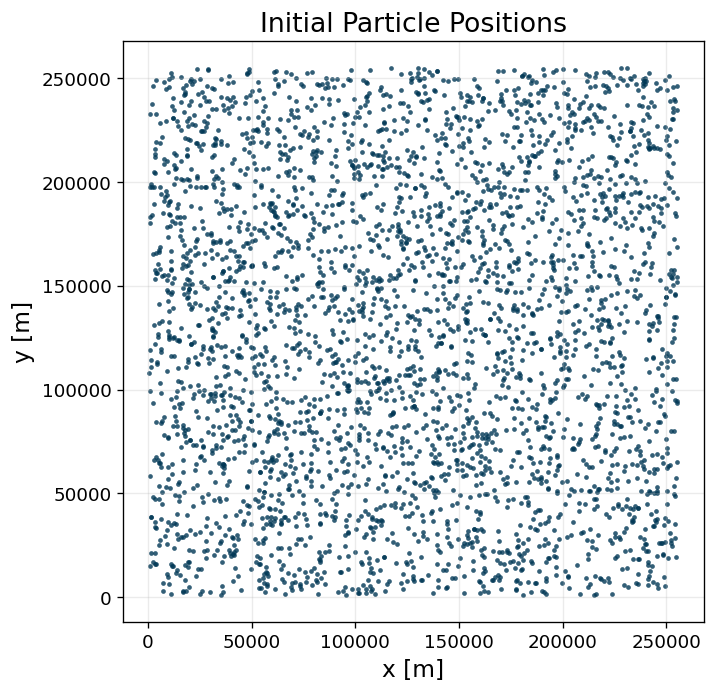


Runtime settings
  forcing time steps    : 160
  forcing dt            : 10800 s
  release index         : 0
  max available runtime : 19.875 days
  selected runtime      : 14.000 days

Particle model convention
  Passive tracer : tau_eff = 0
  SM-MRG particle: tau_eff is prescribed as a sensitivity parameter
  Coriolis term   : enabled with f0 = 8.000e-05 s^-1
  Diameter, buoyancy, viscosity, and drag correction are not prescribed explicitly.
  characteristic T_flow : 19.001 days
  temporary forcing     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\_temporary_parcels_forcing\run_may1_k0_centered_velocity_derivatives.nc


In [ ]:
# ============================================================
# 6. CHECK RUNCONFIG AND INPUT FIELD
# ============================================================

from typing_extensions import runtime


required_runconfig_fields = {
    "input_nc",
    "output_path",
    "runtime_days",
    "dt_seconds",
    "outputdt_seconds",
    "time_step_seconds",
    "release_time_index",
    "periodic",
    "level_indices",
    "release_margin_cells",
    "particle_class",
    "particle_tag",
    "particle_label",
    "tau_p_seconds",
    "tau_eff_seconds",
    "tau_s_seconds",
    "stokes_number_physical",
    "stokes_number_drag_adjusted",
    "B",
    "diameter_m",
    "rho_p_kg_m3",
    "rho_f_kg_m3",
    "nu_m2_s",
    "drag_correction",
    "f0",
    "flow_timescale_seconds",
}

available_runconfig_fields = {f.name for f in fields(prun.RunConfig)}
missing = required_runconfig_fields - available_runconfig_fields

if missing:
    raise RuntimeError(
        "RunConfig is missing required effective-response fields:\n"
        f"{sorted(missing)}\n\n"
        "The existing scripts/run.py must retain tau_p_seconds as the compatibility field used to pass tau_eff."
    )

# Optional warning only: these old fields should no longer be used in the notebook.
deprecated_fields = {
    "B",
    "diameter_m",
    "nu_m2_s",
    "drag_correction",
    "C_Rep",
    "Rep_max",
}

still_present = deprecated_fields & available_runconfig_fields
if still_present:
    print(
        "Note: old diameter/buoyancy/drag fields still exist in RunConfig, "
        "but this notebook will not use them:"
    )
    print(f"  {sorted(still_present)}")


# ============================================================
# 7. MEMORY-LIGHT PREPROCESSING HELPERS
# ============================================================

def _json_ready(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {k: _json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_ready(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, float) and not np.isfinite(obj):
        return None
    return obj


def _find_vertical_dim(ds_source):
    for dim in ds_source["UVEL"].dims:
        if dim.startswith("Z") or dim.lower() in {
            "z", "depth", "k", "level", "lev"
        }:
            return dim

    raise ValueError(
        "Could not detect the vertical dimension from UVEL dims: "
        f"{ds_source['UVEL'].dims}"
    )


def _load_centered_uv_snapshot(ds_source, time_index, z_dim, level_indices):
    """Load and centre one MITgcm time slice using only 2-D arrays."""
    if len(level_indices) == 0:
        raise ValueError("LEVEL_INDICES may not be empty.")

    U_sum = None
    V_sum = None

    for level_index in level_indices:
        u_face = np.asarray(
            ds_source["UVEL"].isel(
                {"T": int(time_index), z_dim: int(level_index)}
            ).values,
            dtype=np.float32,
        )
        v_face = np.asarray(
            ds_source["VVEL"].isel(
                {"T": int(time_index), z_dim: int(level_index)}
            ).values,
            dtype=np.float32,
        )

        U_level = np.float32(0.5) * (
            u_face[:, :-1] + u_face[:, 1:]
        )
        V_level = np.float32(0.5) * (
            v_face[:-1, :] + v_face[1:, :]
        )

        if U_sum is None:
            U_sum = U_level.astype(np.float32, copy=True)
            V_sum = V_level.astype(np.float32, copy=True)
        else:
            U_sum += U_level
            V_sum += V_level

        del u_face, v_face, U_level, V_level

    if len(level_indices) > 1:
        U_sum /= np.float32(len(level_indices))
        V_sum /= np.float32(len(level_indices))

    return U_sum, V_sum


def _gradient_axis_float32(array, spacing, axis):
    """Match the finite differences used by the current fieldset.py."""
    array = np.asarray(array, dtype=np.float32)
    spacing = float(spacing)

    if spacing <= 0.0:
        raise ValueError("Gradient spacing must be positive.")

    out = np.empty_like(array, dtype=np.float32)
    all_slices = [slice(None)] * array.ndim

    middle = all_slices.copy()
    plus = all_slices.copy()
    minus = all_slices.copy()
    middle[axis] = slice(1, -1)
    plus[axis] = slice(2, None)
    minus[axis] = slice(None, -2)
    out[tuple(middle)] = (
        array[tuple(plus)] - array[tuple(minus)]
    ) / np.float32(2.0 * spacing)

    lower = all_slices.copy()
    lower_next = all_slices.copy()
    lower[axis] = 0
    lower_next[axis] = 1
    out[tuple(lower)] = (
        array[tuple(lower_next)] - array[tuple(lower)]
    ) / np.float32(spacing)

    upper = all_slices.copy()
    upper_previous = all_slices.copy()
    upper[axis] = -1
    upper_previous[axis] = -2
    out[tuple(upper)] = (
        array[tuple(upper)] - array[tuple(upper_previous)]
    ) / np.float32(spacing)

    return out


def release_deferred_file_handles(wait_seconds=0.25):
    """
    Release file handles retained by Parcels/xarray deferred loading.

    This is mainly needed on Windows before deleting the temporary
    NetCDF forcing file.
    """
    try:
        pygc.collect()
    except Exception:
        pass

    try:
        from xarray.backends.file_manager import FILE_CACHE
        FILE_CACHE.clear()
    except Exception:
        pass

    try:
        pygc.collect()
    except Exception:
        pass

    time_module.sleep(float(wait_seconds))


def create_temporary_deferred_forcing(
    source_path,
    output_path,
    *,
    level_indices,
    time_step_seconds,
    compression_level=1,
    chunk_y=128,
    chunk_x=128,
):
    """
    Stream centred U/V and the six existing derivative fields to NetCDF.

    Only three source time slices and a small set of 2-D work arrays are held
    in memory. The resulting file contains the same fields required by the
    horizontal slow-manifold-inspired kernel:

        U, V, dUdt, dVdt, dUdx, dUdy, dVdx, dVdy
    """
    source_path = Path(source_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        output_path.unlink()

    with xr.open_dataset(
        source_path,
        decode_times=False,
        cache=False,
    ) as ds_source:
        if "UVEL" not in ds_source or "VVEL" not in ds_source:
            raise KeyError("The input file must contain UVEL and VVEL.")

        z_dim = _find_vertical_dim(ds_source)
        nz = int(ds_source.sizes[z_dim])

        for level_index in level_indices:
            if level_index < 0 or level_index >= nz:
                raise IndexError(
                    f"Requested level {level_index}, but {z_dim} has size {nz}."
                )

        x = np.asarray(ds_source["X"].values, dtype=np.float64)
        y = np.asarray(ds_source["Y"].values, dtype=np.float64)
        nt = int(ds_source.sizes["T"])
        ny = int(y.size)
        nx = int(x.size)

        dx = float(np.nanmedian(np.diff(x)))
        dy = float(np.nanmedian(np.diff(y)))
        dt = float(time_step_seconds)
        relative_time = np.arange(nt, dtype=np.float64) * dt

        chunksizes = (
            1,
            min(int(chunk_y), ny),
            min(int(chunk_x), nx),
        )

        with NetCDFDataset(output_path, mode="w", format="NETCDF4") as dst:
            dst.createDimension("time", nt)
            dst.createDimension("y", ny)
            dst.createDimension("x", nx)

            time_var = dst.createVariable("time", "f8", ("time",))
            y_var = dst.createVariable("y", "f8", ("y",))
            x_var = dst.createVariable("x", "f8", ("x",))

            time_var[:] = relative_time
            y_var[:] = y
            x_var[:] = x

            time_var.units = "seconds"
            time_var.long_name = "time since first forcing snapshot"
            x_var.units = "m"
            y_var.units = "m"

            output_variables = {}
            variable_units = {
                "U": "m s-1",
                "V": "m s-1",
                "dUdt": "m s-2",
                "dVdt": "m s-2",
                "dUdx": "s-1",
                "dUdy": "s-1",
                "dVdx": "s-1",
                "dVdy": "s-1",
            }

            for name, units in variable_units.items():
                output_var = dst.createVariable(
                    name,
                    "f4",
                    ("time", "y", "x"),
                    zlib=True,
                    complevel=int(compression_level),
                    shuffle=True,
                    chunksizes=chunksizes,
                )
                output_var.units = units
                output_variables[name] = output_var

            dst.source_file = str(source_path)
            dst.level_indices = ",".join(str(k) for k in level_indices)
            dst.time_step_seconds = dt
            dst.description = (
                "Temporary Parcels forcing with tracer-centred velocity and "
                "finite-difference derivatives for deferred loading."
            )

            U_previous = None
            V_previous = None
            U_current, V_current = _load_centered_uv_snapshot(
                ds_source,
                0,
                z_dim,
                level_indices,
            )

            if nt > 1:
                U_next, V_next = _load_centered_uv_snapshot(
                    ds_source,
                    1,
                    z_dim,
                    level_indices,
                )
            else:
                U_next = None
                V_next = None

            for time_index in range(nt):
                if nt == 1:
                    dUdt = np.zeros_like(U_current, dtype=np.float32)
                    dVdt = np.zeros_like(V_current, dtype=np.float32)
                elif time_index == 0:
                    dUdt = (U_next - U_current) / np.float32(dt)
                    dVdt = (V_next - V_current) / np.float32(dt)
                elif time_index == nt - 1:
                    dUdt = (U_current - U_previous) / np.float32(dt)
                    dVdt = (V_current - V_previous) / np.float32(dt)
                else:
                    dUdt = (U_next - U_previous) / np.float32(2.0 * dt)
                    dVdt = (V_next - V_previous) / np.float32(2.0 * dt)

                dUdx = _gradient_axis_float32(U_current, dx, axis=1)
                dUdy = _gradient_axis_float32(U_current, dy, axis=0)
                dVdx = _gradient_axis_float32(V_current, dx, axis=1)
                dVdy = _gradient_axis_float32(V_current, dy, axis=0)

                output_variables["U"][time_index, :, :] = U_current
                output_variables["V"][time_index, :, :] = V_current
                output_variables["dUdt"][time_index, :, :] = dUdt
                output_variables["dVdt"][time_index, :, :] = dVdt
                output_variables["dUdx"][time_index, :, :] = dUdx
                output_variables["dUdy"][time_index, :, :] = dUdy
                output_variables["dVdx"][time_index, :, :] = dVdx
                output_variables["dVdy"][time_index, :, :] = dVdy

                if time_index % 10 == 0 or time_index == nt - 1:
                    print(f"  preprocessing time {time_index + 1:4d}/{nt}")
                    dst.sync()

                del dUdt, dVdt, dUdx, dUdy, dVdx, dVdy

                if time_index < nt - 1:
                    U_previous, V_previous = U_current, V_current
                    U_current, V_current = U_next, V_next

                    next_index = time_index + 2
                    if next_index < nt:
                        U_next, V_next = _load_centered_uv_snapshot(
                            ds_source,
                            next_index,
                            z_dim,
                            level_indices,
                        )
                    else:
                        U_next = None
                        V_next = None

            del U_previous, V_previous, U_current, V_current, U_next, V_next

    release_deferred_file_handles()
    return output_path


def build_deferred_fieldset(
    temporary_path,
    *,
    include_derivatives,
    periodic,
    chunksize="auto",
):
    variables = {"U": "U", "V": "V"}

    if include_derivatives:
        variables.update(
            {
                "dUdt": "dUdt",
                "dVdt": "dVdt",
                "dUdx": "dUdx",
                "dUdy": "dUdy",
                "dVdx": "dVdx",
                "dVdy": "dVdy",
            }
        )

    filenames = {
        parcels_name: str(temporary_path)
        for parcels_name in variables
    }
    dimensions = {
        parcels_name: {
            "lon": "x",
            "lat": "y",
            "time": "time",
        }
        for parcels_name in variables
    }

    fieldset = FieldSet.from_netcdf(
        filenames=filenames,
        variables=variables,
        dimensions=dimensions,
        mesh="flat",
        deferred_load=True,
        chunksize=chunksize,
        allow_time_extrapolation=False,
    )

    with xr.open_dataset(
        temporary_path,
        decode_times=False,
        cache=False,
    ) as ds_temporary:
        x = np.asarray(ds_temporary["x"].values, dtype=float)
        y = np.asarray(ds_temporary["y"].values, dtype=float)

    dx = float(np.nanmedian(np.diff(x)))
    dy = float(np.nanmedian(np.diff(y)))

    x_edge_min = float(x[0] - 0.5 * dx)
    x_edge_max = float(x[-1] + 0.5 * dx)
    y_edge_min = float(y[0] - 0.5 * dy)
    y_edge_max = float(y[-1] + 0.5 * dy)

    if periodic:
        fieldset.add_periodic_halo(zonal=True, meridional=True)
        fieldset.add_constant("x_edge_min", x_edge_min)
        fieldset.add_constant("x_edge_max", x_edge_max)
        fieldset.add_constant("y_edge_min", y_edge_min)
        fieldset.add_constant("y_edge_max", y_edge_max)
        fieldset.add_constant("Lx", x_edge_max - x_edge_min)
        fieldset.add_constant("Ly", y_edge_max - y_edge_min)

    return fieldset, x, y


def _sample_initial_fluid_velocity(
    temporary_path,
    lon0,
    lat0,
    release_time_index,
):
    """Preserve the original initialization: u_p(t0) = u_f(t0)."""
    particle_index = xr.DataArray(
        np.arange(len(lon0)),
        dims="particle",
    )
    lon_da = xr.DataArray(
        lon0,
        dims="particle",
        coords={"particle": particle_index},
    )
    lat_da = xr.DataArray(
        lat0,
        dims="particle",
        coords={"particle": particle_index},
    )

    with xr.open_dataset(
        temporary_path,
        decode_times=False,
        cache=False,
    ) as ds_temporary:
        snapshot = ds_temporary.isel(time=int(release_time_index))
        U0 = np.asarray(
            snapshot["U"].interp(x=lon_da, y=lat_da).values,
            dtype=float,
        )
        V0 = np.asarray(
            snapshot["V"].interp(x=lon_da, y=lat_da).values,
            dtype=float,
        )

    U0 = np.where(np.isfinite(U0), U0, 0.0)
    V0 = np.where(np.isfinite(V0), V0, 0.0)

    return U0.astype(np.float32), V0.astype(np.float32)


def _metadata_path_for_output(output_path):
    output_path = Path(output_path)
    if output_path.suffix == ".zarr":
        return output_path.with_suffix(".json")
    return output_path.parent / f"{output_path.name}.json"


def _write_metadata_sidecar(output_path, info):
    if hasattr(prun, "_write_metadata_sidecar"):
        return prun._write_metadata_sidecar(Path(output_path), info)

    metadata_path = _metadata_path_for_output(output_path)
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    with open(metadata_path, "w") as metadata_file:
        json.dump(_json_ready(info), metadata_file, indent=2)
    return metadata_path



def delete_with_retries(path, attempts=30, delay_seconds=0.5):
    """
    Delete a file or directory after releasing deferred NetCDF handles.

    Returns True when the path was deleted or did not exist.
    Raises PermissionError only after all retries fail.
    """
    path = Path(path)

    if not path.exists():
        return True

    last_error = None

    for _ in range(int(attempts)):
        release_deferred_file_handles()

        try:
            if path.is_dir():
                shutil.rmtree(path)
            else:
                path.unlink()

            return True

        except (PermissionError, OSError) as exc:
            last_error = exc
            time_module.sleep(float(delay_seconds))

    raise PermissionError(
        f"Could not delete temporary path after retries: {path}"
    ) from last_error



def _prepare_release_positions(config, release_dataset):
    """
    Use the existing grid release unchanged, or generate a reproducible
    independent-uniform random release with NX * NY particles.
    """
    if config.release_mode != "random":
        return prun.prepare_release(config, release_dataset)

    x = np.asarray(release_dataset["x"].values, dtype=float)
    y = np.asarray(release_dataset["y"].values, dtype=float)

    dx = float(np.nanmedian(np.diff(x)))
    dy = float(np.nanmedian(np.diff(y)))
    margin = float(config.release_margin_cells)

    x_min = float(np.nanmin(x) + margin * dx)
    x_max = float(np.nanmax(x) - margin * dx)
    y_min = float(np.nanmin(y) + margin * dy)
    y_max = float(np.nanmax(y) - margin * dy)

    if not (x_max > x_min and y_max > y_min):
        raise ValueError(
            "The release margin leaves no valid random-release area."
        )

    n_particles = int(config.nx) * int(config.ny)
    rng = np.random.default_rng(RANDOM_RELEASE_SEED)

    lon0 = rng.uniform(x_min, x_max, size=n_particles)
    lat0 = rng.uniform(y_min, y_max, size=n_particles)

    return lon0, lat0


def run_parcels_experiment_deferred(config, temporary_forcing_path):
    """
    Memory-light equivalent of prun.run_parcels_experiment().

    The existing RunConfig, particle class, release logic, project kernels,
    effective-response values, f0 value, and flow-timescale metadata are
    retained. Only the FieldSet construction is replaced by deferred loading
    from the temporary forcing file.
    """
    include_derivatives = config.particle_class == "mr_sm"

    fieldset = None
    pset = None
    kernel = None
    particle_file = None

    try:
        fieldset, x, y = build_deferred_fieldset(
            temporary_forcing_path,
            include_derivatives=include_derivatives,
            periodic=config.periodic,
            chunksize=PARCELS_CHUNKSIZE,
        )

        if config.particle_class == "mr_sm":
            fieldset.add_constant("f0", float(config.f0))

        params = prun.particle_class_parameters(config)

        release_dataset = xr.Dataset(
            coords={
                "x": ("x", x),
                "y": ("y", y),
            }
        )

        try:
            lon0, lat0 = _prepare_release_positions(
                config,
                release_dataset,
            )
        finally:
            release_dataset.close()

        forcing_times = np.asarray(fieldset.U.grid.time, dtype=float)

        if (
            config.release_time_index < 0
            or config.release_time_index >= len(forcing_times)
        ):
            raise IndexError(
                f"release_time_index={config.release_time_index} is outside "
                f"0..{len(forcing_times) - 1}."
            )

        release_time = float(forcing_times[config.release_time_index])
        runtime_seconds = float(config.runtime_days) * 86400.0
        requested_end = release_time + runtime_seconds

        if requested_end > float(forcing_times[-1]) + 1.0e-6:
            available_days = (
                float(forcing_times[-1]) - release_time
            ) / 86400.0

            raise ValueError(
                "Requested runtime is too long for the forcing.\n"
                f"Requested: {config.runtime_days:.3f} days\n"
                f"Available: {available_days:.3f} days"
            )

        up0, vp0 = _sample_initial_fluid_velocity(
            temporary_forcing_path,
            lon0,
            lat0,
            config.release_time_index,
        )

        n_particles = len(lon0)
        release_id = np.arange(n_particles, dtype=np.int32)

        output_path = Path(config.output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        pset = ParticleSet.from_list(
            fieldset=fieldset,
            pclass=pparticles.FloatingParticle,
            lon=lon0,
            lat=lat0,
            time=np.full(n_particles, release_time, dtype=float),
            release_id=release_id,
            particle_class_id=np.full(
                n_particles,
                int(params["particle_class_id"]),
                dtype=np.int32,
            ),
            drag_mode_id=np.full(
                n_particles,
                int(params["drag_mode_id"]),
                dtype=np.int32,
            ),
            B=np.ones(n_particles, dtype=np.float32),
            diameter=np.zeros(n_particles, dtype=np.float32),
            tau_p=np.full(
                n_particles,
                float(params["tau_p_seconds"]),
                dtype=np.float32,
            ),
            tau_eff_nominal=np.full(
                n_particles,
                float(params["tau_eff_nominal_seconds"]),
                dtype=np.float32,
            ),
            C_Rep=np.ones(n_particles, dtype=np.float32),
            stokes_number=np.full(
                n_particles,
                float(params["stokes_number"]),
                dtype=np.float32,
            ),
            Rep=np.zeros(n_particles, dtype=np.float32),
            uslip=np.zeros(n_particles, dtype=np.float32),
            vslip=np.zeros(n_particles, dtype=np.float32),
            C_Rep_current=np.ones(n_particles, dtype=np.float32),
            up=up0,
            vp=vp0,
        )

        if config.particle_class == "passive":
            kernel = pset.Kernel(kpassive.advection_passive_rk4)

        elif config.particle_class == "mr_sm":
            kernel = pset.Kernel(kmrsm.advection_mr_sm_rk4)

        else:
            raise ValueError(
                f"Unknown particle_class: {config.particle_class}"
            )

        if config.periodic:
            kernel += pset.Kernel(kcommon.periodic_xy)

        particle_file = pset.ParticleFile(
            name=str(output_path),
            outputdt=timedelta(
                seconds=float(config.outputdt_seconds)
            ),
        )

        runtime_delta = timedelta(seconds=runtime_seconds)
        dt_delta = timedelta(seconds=float(config.dt_seconds))

        with pywarnings.catch_warnings():
            pywarnings.filterwarnings(
                "ignore",
                message=r".*'where' used without 'out'.*",
                category=UserWarning,
            )

            pset.execute(
                kernel,
                runtime=runtime_delta,
                dt=dt_delta,
                output_file=particle_file,
                verbose_progress=True,
            )

        info = {
            **params,
            "input_nc": str(config.input_nc),
            "output_path": str(output_path),
            "n_particles": int(n_particles),
            "release_time_index": int(config.release_time_index),
            "release_time_seconds": float(release_time),
            "release_time_days": float(release_time / 86400.0),
            "runtime_days": float(config.runtime_days),
            "dt_seconds": int(config.dt_seconds),
            "outputdt_seconds": int(config.outputdt_seconds),
            "time_step_seconds": int(config.time_step_seconds),
            "surface_only": bool(config.surface_only),
            "periodic": bool(config.periodic),
            "level_indices": tuple(config.level_indices),
            "particle_class": config.particle_class,
            "tau_p_seconds": float(params["tau_p_seconds"]),
            "tau_eff_seconds": float(
                params["tau_eff_nominal_seconds"]
            ),
            "particle_model": (
                "horizontal_sm_mrg_acceleration_plus_coriolis"
            ),
            "explicit_coriolis": True,
            "f0": float(config.f0),
            "flow_timescale_seconds": (
                None
                if config.flow_timescale_seconds is None
                else float(config.flow_timescale_seconds)
            ),
            "initial_particle_velocity": getattr(
                config,
                "initial_particle_velocity",
                "fluid",
            ),
            "u_name": "UVEL",
            "v_name": "VVEL",
            "add_derivatives": bool(include_derivatives),
            "forcing_memory_strategy": (
                "temporary chunked NetCDF with deferred Parcels loading"
            ),
            "temporary_forcing_path_during_run": str(
                temporary_forcing_path
            ),
            "config": asdict(config),
        }

        if config.save_metadata_sidecar:
            metadata_path = _write_metadata_sidecar(
                output_path,
                info,
            )
            info["metadata_path"] = str(metadata_path)

        if hasattr(prun, "_add_attrs_to_zarr_if_possible"):
            prun._add_attrs_to_zarr_if_possible(
                output_path,
                info,
            )

        return info

    finally:
        if (
            particle_file is not None
            and hasattr(particle_file, "close")
        ):
            try:
                particle_file.close()
            except Exception:
                pass

        particle_file = None
        kernel = None
        pset = None
        fieldset = None

        release_deferred_file_handles()


# ============================================================
# 8. LIGHTWEIGHT INPUT QC AND RUNTIME SELECTION
# ============================================================

raw_qc = pfs.summarize_dataset(DATA_FILE)

print("\nRaw MITgcm input QC")
print(f"  dims      : {raw_qc.get('dims')}")
print(f"  U dims    : {raw_qc.get('u_dims', 'not reported')}")
print(f"  V dims    : {raw_qc.get('v_dims', 'not reported')}")
print(f"  x center  : {raw_qc.get('x_center', raw_qc.get('x_name', 'unknown'))}")
print(f"  y center  : {raw_qc.get('y_center', raw_qc.get('y_name', 'unknown'))}")
print(f"  U var     : {raw_qc.get('u_name')}")
print(f"  V var     : {raw_qc.get('v_name')}")

with xr.open_dataset(
    DATA_FILE,
    decode_times=False,
    cache=False,
) as ds_source_qc:
    z_dim_qc = _find_vertical_dim(ds_source_qc)
    n_forcing_times = int(ds_source_qc.sizes["T"])

    U_qc, V_qc = _load_centered_uv_snapshot(
        ds_source_qc,
        RELEASE_TIME_INDEX,
        z_dim_qc,
        LEVEL_INDICES,
    )

    x_qc = np.asarray(ds_source_qc["X"].values, dtype=float)
    y_qc = np.asarray(ds_source_qc["Y"].values, dtype=float)

print("\nParcels-ready field QC (single snapshot only)")
print(f"  U shape   : {U_qc.shape}")
print(f"  V shape   : {V_qc.shape}")
print(f"  x range   : {np.nanmin(x_qc):.1f} to {np.nanmax(x_qc):.1f} m")
print(f"  y range   : {np.nanmin(y_qc):.1f} to {np.nanmax(y_qc):.1f} m")
print(f"  n time    : {n_forcing_times}")
print(f"  U NaN t0  : {np.mean(~np.isfinite(U_qc)):.6f}")
print(f"  V NaN t0  : {np.mean(~np.isfinite(V_qc)):.6f}")

# Use the same release helper as the production runs.
release_qc_dataset = xr.Dataset(
    coords={
        "x": ("x", x_qc),
        "y": ("y", y_qc),
    }
)

release_qc_config = prun.RunConfig(
    input_nc=str(DATA_FILE),
    output_path=str(RUN_OUT_DIR / "_release_qc_unused.zarr"),
    runtime_days=RUNTIME_DAYS_REQUESTED,
    dt_seconds=DT_SECONDS,
    outputdt_seconds=OUTPUTDT_SECONDS,
    time_step_seconds=TIME_STEP_SECONDS,
    release_time_index=RELEASE_TIME_INDEX,
    surface_only=True,
    mesh="flat",
    periodic=PERIODIC,
    level_indices=LEVEL_INDICES,
    release_mode=RELEASE_MODE,
    nx=NX,
    ny=NY,
    release_margin_cells=RELEASE_MARGIN_CELLS,
    particle_class="passive",
    particle_tag="release_qc",
    particle_label="Release QC",
    tau_p_seconds=0.0,
    f0=F0,
    flow_timescale_seconds=FLOW_TIMESCALE_SECONDS,
    save_metadata_sidecar=False,
)

initial_x_qc, initial_y_qc = _prepare_release_positions(
    release_qc_config,
    release_qc_dataset,
)
release_qc_dataset.close()

fig, ax = plt.subplots(figsize=(7.0, 6.0))
ax.scatter(
    initial_x_qc,
    initial_y_qc,
    s=8,
    alpha=0.8,
    linewidths=0.0,
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Initial Particle Positions")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

del initial_x_qc, initial_y_qc
del U_qc, V_qc, x_qc, y_qc
release_deferred_file_handles()

if RELEASE_TIME_INDEX < 0 or RELEASE_TIME_INDEX >= n_forcing_times:
    raise ValueError(
        f"RELEASE_TIME_INDEX={RELEASE_TIME_INDEX} is outside the available "
        f"forcing range 0 to {n_forcing_times - 1}."
    )

max_runtime_days = (
    (n_forcing_times - 1 - RELEASE_TIME_INDEX)
    * TIME_STEP_SECONDS
    / 86400.0
)

if RUNTIME_MODE == "full_forcing":
    RUNTIME_DAYS = max_runtime_days
elif RUNTIME_MODE == "manual":
    RUNTIME_DAYS = float(RUNTIME_DAYS_REQUESTED)

    if RUNTIME_DAYS > max_runtime_days:
        raise ValueError(
            "Requested runtime is too long.\n"
            f"Requested runtime : {RUNTIME_DAYS:.3f} days\n"
            f"Available runtime : {max_runtime_days:.3f} days\n"
            "Use RUNTIME_MODE='full_forcing' or reduce "
            "RUNTIME_DAYS_REQUESTED."
        )
else:
    raise ValueError(f"Unknown RUNTIME_MODE: {RUNTIME_MODE}")

print("\nRuntime settings")
print(f"  forcing time steps    : {n_forcing_times}")
print(f"  forcing dt            : {TIME_STEP_SECONDS} s")
print(f"  release index         : {RELEASE_TIME_INDEX}")
print(f"  max available runtime : {max_runtime_days:.3f} days")
print(f"  selected runtime      : {RUNTIME_DAYS:.3f} days")

print("\nParticle model convention")
print("  Passive tracer : tau_eff = 0")
print("  SM-MRG particle: tau_eff is prescribed as a sensitivity parameter")
print(f"  Coriolis term   : enabled with f0 = {F0:.3e} s^-1")
print("  Diameter, buoyancy, viscosity, and drag correction are not prescribed explicitly.")
print(f"  characteristic T_flow : {FLOW_TIMESCALE_DAYS:.3f} days")
print(f"  temporary forcing     : {TEMP_FORCING_PATH}")


In [18]:
# ============================================================
# 9. PARCELS ADVECTION
# One trajectory file per particle class.
# ============================================================

run_outputs = {}

try:
    if RUN_ADVECTION:
        if REBUILD_TEMPORARY_FORCING and TEMP_FORCING_DIR.exists():
            print(
                "\nRemoving stale temporary forcing folder before rebuilding:"
                f"\n  {TEMP_FORCING_DIR}"
            )
            delete_with_retries(TEMP_FORCING_DIR)

        if REBUILD_TEMPORARY_FORCING or not TEMP_FORCING_PATH.exists():
            print(
                "\nCreating temporary deferred forcing file:"
                f"\n  {TEMP_FORCING_PATH}"
            )
            create_temporary_deferred_forcing(
                DATA_FILE,
                TEMP_FORCING_PATH,
                level_indices=LEVEL_INDICES,
                time_step_seconds=TIME_STEP_SECONDS,
                compression_level=TEMP_COMPRESSION_LEVEL,
                chunk_y=TEMP_CHUNK_Y,
                chunk_x=TEMP_CHUNK_X,
            )
        else:
            print(
                "\nUsing existing temporary deferred forcing file:"
                f"\n  {TEMP_FORCING_PATH}"
            )

        with xr.open_dataset(
            TEMP_FORCING_PATH,
            decode_times=False,
            cache=False,
        ) as ds_temporary_qc:
            required_temporary_variables = {
                "U",
                "V",
                "dUdt",
                "dVdt",
                "dUdx",
                "dUdy",
                "dVdx",
                "dVdy",
            }
            missing_temporary_variables = (
                required_temporary_variables
                - set(ds_temporary_qc.data_vars)
            )

            if missing_temporary_variables:
                raise RuntimeError(
                    "Temporary forcing is missing variables: "
                    f"{sorted(missing_temporary_variables)}"
                )

            if ds_temporary_qc.sizes["time"] != n_forcing_times:
                raise RuntimeError(
                    "Temporary forcing does not contain the full forcing period."
                )

            print("\nTemporary forcing QC")
            print(f"  dims      : {dict(ds_temporary_qc.sizes)}")
            print(f"  U shape   : {tuple(ds_temporary_qc['U'].shape)}")
            print(f"  U dtype   : {ds_temporary_qc['U'].dtype}")
            print(f"  full time : {ds_temporary_qc.sizes['time'] == n_forcing_times}")

    for spec in particle_specs:
        particle_tag = spec["tag"]
        particle_label = spec.get("label", particle_tag)
        particle_class = spec["particle_class"]

        tau_eff_seconds = float(
            spec.get("tau_eff_seconds", spec.get("tau_p_seconds", 0.0))
        )

        if particle_class == "mr_sm" and tau_eff_seconds <= 0.0:
            raise ValueError(
                f"SM-MRG particle '{particle_tag}' needs tau_eff_seconds > 0.\n"
                f"Current spec:\n{spec}"
            )

        if particle_class == "passive":
            tau_eff_seconds = 0.0

        run_id = (
            f"{particle_tag}_{level_tag}_"
            f"release_t{RELEASE_TIME_INDEX:04d}"
        )
        out_zarr = RUN_OUT_DIR / f"{run_id}.zarr"
        metadata_json = out_zarr.with_suffix(".json")

        if OVERWRITE_OUTPUT and RUN_ADVECTION and out_zarr.exists():
            delete_with_retries(out_zarr)

        if OVERWRITE_OUTPUT and RUN_ADVECTION and metadata_json.exists():
            delete_with_retries(metadata_json)

        if RUN_ADVECTION:
            config = prun.RunConfig(
                input_nc=str(DATA_FILE),
                output_path=str(out_zarr),

                runtime_days=RUNTIME_DAYS,
                dt_seconds=DT_SECONDS,
                outputdt_seconds=OUTPUTDT_SECONDS,
                time_step_seconds=TIME_STEP_SECONDS,
                release_time_index=RELEASE_TIME_INDEX,

                surface_only=True,
                mesh="flat",
                periodic=PERIODIC,
                level_indices=LEVEL_INDICES,

                release_mode=RELEASE_MODE,
                nx=NX,
                ny=NY,
                release_margin_cells=RELEASE_MARGIN_CELLS,

                particle_class=particle_class,
                particle_tag=particle_tag,
                particle_label=particle_label,

                # RunConfig retains the name tau_p_seconds for compatibility,
                # but the value is the prescribed effective response
                # coefficient tau_eff used by the SM-MRG kernel.
                tau_p_seconds=tau_eff_seconds,

                # Constant f-plane Coriolis parameter used in the horizontal
                # slow-manifold correction.
                f0=F0,

                # Preserve the user's characteristic timescale and St definition.
                flow_timescale_seconds=spec.get(
                    "flow_timescale_seconds",
                    FLOW_TIMESCALE_SECONDS,
                ),

                save_metadata_sidecar=True,
            )

            print(f"\nRunning {particle_tag}")
            print(f"  class       : {particle_class}")
            print(f"  label       : {particle_label}")
            print(f"  tau_eff     : {tau_eff_seconds:.3g} s")
            print(
                "  T_flow      : "
                f"{config.flow_timescale_seconds / 86400.0:.3f} days"
            )
            print(f"  St_eff      : {spec.get('stokes_number_eff', np.nan):.6g}")
            print(f"  tau_eff*f0  : {tau_eff_seconds * abs(F0):.6g}")
            print(f"  runtime     : {RUNTIME_DAYS:.3f} days")
            print(f"  field load  : deferred ({PARCELS_CHUNKSIZE!r})")

            info = run_parcels_experiment_deferred(
                config,
                TEMP_FORCING_PATH,
            )

        else:
            if not out_zarr.exists():
                raise FileNotFoundError(
                    "RUN_ADVECTION=False, but output does not exist:\n"
                    f"{out_zarr}"
                )

            if metadata_json.exists():
                info = prun.load_run_metadata(metadata_json)
            else:
                info = {
                    "particle_tag": particle_tag,
                    "particle_label": particle_label,
                    "particle_class": particle_class,
                    "tau_p_seconds": tau_eff_seconds,
                    "tau_eff_seconds": tau_eff_seconds,
                    "output_path": str(out_zarr),
                }

        run_outputs[particle_tag] = {
            "path": str(out_zarr),
            "metadata_path": str(metadata_json),
            "label": info.get("particle_label", particle_label),
            "info": info,
            "spec": spec,
        }

        print(f"  output   : {out_zarr}")
        print(f"  metadata : {metadata_json}")

finally:
    # Do not delete the temporary forcing here. Metadata is saved first.
    release_deferred_file_handles()


# ============================================================
# 10. SAVE COLLECTION METADATA
# ============================================================

flow_timescale_seconds_json = (
    None
    if FLOW_TIMESCALE_SECONDS is None
    else float(FLOW_TIMESCALE_SECONDS)
)

config_dict = {
    # --------------------------------------------------------
    # Collection identification
    # --------------------------------------------------------
    "created_utc": datetime.utcnow().isoformat() + "Z",
    "case_name": case_name,
    "run_collection_id": run_collection_id,

    # --------------------------------------------------------
    # Input/output locations
    # --------------------------------------------------------
    "input_nc": str(DATA_FILE),
    "case_results_dir": str(CASE_RESULTS_DIR),
    "trajectory_dir": str(RUN_OUT_DIR),

    # --------------------------------------------------------
    # Release configuration
    # --------------------------------------------------------
    "release_time_index": int(RELEASE_TIME_INDEX),
    "release_time_days": float(release_time_days),
    "level_indices": list(LEVEL_INDICES),
    "nx": int(NX),
    "ny": int(NY),
    "release_mode": RELEASE_MODE,
    "random_release_seed": int(RANDOM_RELEASE_SEED),
    "periodic": bool(PERIODIC),
    "release_margin_cells": float(RELEASE_MARGIN_CELLS),
    "runtime_mode": RUNTIME_MODE,
    "runtime_days": float(RUNTIME_DAYS),
    "dt_seconds": int(DT_SECONDS),
    "outputdt_seconds": int(OUTPUTDT_SECONDS),
    "time_step_seconds": int(TIME_STEP_SECONDS),

    "particle_convention": (
        "Passive particles use tau_eff=0. Inertial particles use a prescribed "
        "effective response coefficient tau_eff multiplying the sum of the "
        "horizontal fluid material acceleration and the Coriolis contribution. "
        "The internal RunConfig field tau_p_seconds stores tau_eff for compatibility. "
        "Diameter, buoyancy, viscosity, particle Reynolds number, and drag "
        "correction are not prescribed explicitly."
    ),

    "tau_eff_interpretation": (
        "Effective response coefficient multiplying D_h u_f/Dt + "
        "f0 z_hat cross u_f; not a physical Stokes relaxation time."
    ),

    "explicit_coriolis": True,
    "f0": float(F0),
    "eddy_turnover_case_name": ETT_CASE_NAME,
    "eddy_turnover_time_json": str(ETT_JSON),

    "median_eddy_turnover_time_days": float(
        MEDIAN_EDDY_TURNOVER_DAYS
    ),

    "flow_timescale_multiplier": 0.5,

    "flow_timescale_definition": (
        "T_flow = 0.5 * median_T_eddy_days"
    ),

    "flow_timescale_days": float(FLOW_TIMESCALE_DAYS),
    "flow_timescale_seconds": float(FLOW_TIMESCALE_SECONDS),

    "stokes_number_definition": (
        "St_eff = tau_eff_seconds / flow_timescale_seconds"
    ),
    "particle_tag_convention": (
        "passive for tracers; smmrg_taueff{seconds}s_Steff{value} "
        "for slow-manifold-inspired inertial particles"
    ),
    "particle_specs": particle_specs,
    "run_outputs": run_outputs,

    # Memory strategy only; no physical/model settings are changed.
    "forcing_memory_strategy": (
        "streamed temporary chunked NetCDF containing centred U/V and the "
        "six existing derivative fields; Parcels FieldSet.from_netcdf with "
        "deferred loading"
    ),
    "temporary_forcing_deleted": False,
}

if SAVE_METADATA:
    CONFIG_JSON.parent.mkdir(parents=True, exist_ok=True)

    with open(CONFIG_JSON, "w", encoding="utf-8") as config_file:
        json.dump(
            _json_ready(config_dict),
            config_file,
            indent=2,
        )

    print(f"\nSaved collection metadata: {CONFIG_JSON}")


# ============================================================
# 11. DELETE TEMPORARY FORCING
# Trajectories and metadata are preserved.
# ============================================================

temporary_forcing_deleted = not TEMP_FORCING_DIR.exists()

if DELETE_TEMPORARY_FORCING and TEMP_FORCING_DIR.exists():
    print(
        "\nDeleting temporary forcing folder:"
        f"\n  {TEMP_FORCING_DIR}"
    )

    try:
        release_deferred_file_handles(wait_seconds=0.5)
        delete_with_retries(
            TEMP_FORCING_DIR,
            attempts=30,
            delay_seconds=0.5,
        )
        temporary_forcing_deleted = not TEMP_FORCING_DIR.exists()

    except PermissionError as exc:
        temporary_forcing_deleted = False
        print(
            "  WARNING: the temporary forcing folder is still locked "
            "and could not be deleted."
        )
        print(f"  {exc}")

    print(
        "  temporary folder exists after cleanup: "
        f"{TEMP_FORCING_DIR.exists()}"
    )

config_dict["temporary_forcing_deleted"] = bool(
    temporary_forcing_deleted
)

if SAVE_METADATA:
    with open(CONFIG_JSON, "w", encoding="utf-8") as config_file:
        json.dump(
            _json_ready(config_dict),
            config_file,
            indent=2,
        )

print("\nDone. Use this in the analysis notebook:")
print(f"RUN_COLLECTION_ID = {run_collection_id!r}")



Creating temporary deferred forcing file:
  C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\_temporary_parcels_forcing\run_may1_k0_centered_velocity_derivatives.nc
  preprocessing time    1/160
  preprocessing time   11/160
  preprocessing time   21/160
  preprocessing time   31/160
  preprocessing time   41/160
  preprocessing time   51/160
  preprocessing time   61/160
  preprocessing time   71/160
  preprocessing time   81/160
  preprocessing time   91/160
  preprocessing time  101/160
  preprocessing time  111/160
  preprocessing time  121/160
  preprocessing time  131/160
  preprocessing time  141/160
  preprocessing time  151/160
  preprocessing time  160/160

Temporary forcing QC
  dims      : {'time': 160, 'y': 512, 'x': 512}
  U shape   : (160, 512, 512)
  U dtype   : float32
  full time : True

Running passive
  class       : passive
  label       : Tracer
  tau_eff     : 0 s
  T_flow      : 19.001 days
  St_eff      : 0
  tau_eff*f0  : 0

c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\ast.py:407: KernelWarning: Don't change the location of a particle directly in a Kernel. Use particle_dlon, particle_dlat, etc.
  return visitor(node)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\field.py:1184: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\passive_k0_release_t0000.zarr.
100%|██████████| 1209600.0/1209600.0 [02:01<00:00, 9957.48it/s]
  output   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\passive_k0_release_t0000.zarr
  metadata : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\passive_k0_release_t0000.json

Running smmrg_taueff30s_Steff1p82742em05
  class       : mr_sm
  label       : SM-MRG, tau_eff=0.00833333 h, St_eff=1.83e-05
  tau_eff     : 30 s
  T_flow      : 19.001 days
  St_eff      : 1.82742e-05
  tau_eff*f0  : 0.0024
  runtime     : 14.000 days
  field load  : deferred ('auto')


c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\ast.py:407: KernelWarning: Don't change the location of a particle directly in a Kernel. Use particle_dlon, particle_dlat, etc.
  return visitor(node)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\field.py:1184: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff30s_Steff1p82742em05_k0_release_t0000.zarr.
100%|██████████| 1209600.0/1209600.0 [05:25<00:00, 3717.06it/s]
  output   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff30s_Steff1p82742em05_k0_release_t0000.zarr
  metadata : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff30s_Steff1p82742em05_k0_release_t0000.json

Running smmrg_taueff60s_Steff3p65483em05
  class       : mr_sm
  label       : SM-MRG, tau_eff=0.0166667 h, St_eff=3.65e-05
  tau_eff     : 60 s
  T_flow      : 19.001 days
  St_eff      : 3.65483e-05
  tau_eff*f0  : 0.0048
  runtime     : 14.000 days
  field load  : deferred ('auto')


c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\ast.py:407: KernelWarning: Don't change the location of a particle directly in a Kernel. Use particle_dlon, particle_dlat, etc.
  return visitor(node)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\field.py:1184: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff60s_Steff3p65483em05_k0_release_t0000.zarr.
100%|██████████| 1209600.0/1209600.0 [05:16<00:00, 3825.18it/s]
  output   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff60s_Steff3p65483em05_k0_release_t0000.zarr
  metadata : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\trajectories\smmrg_taueff60s_Steff3p65483em05_k0_release_t0000.json


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_33552\173510510.py:215: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",



Saved collection metadata: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\metadata\passive_plus_smmrg_k0_release_t0000_config.json

Deleting temporary forcing folder:
  C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_may1\_temporary_parcels_forcing
  temporary folder exists after cleanup: False

Done. Use this in the analysis notebook:
RUN_COLLECTION_ID = 'passive_plus_smmrg_k0_release_t0000'
